#Edward Moswane Assignment 15: Loan Default Prediction


## Task 1: Data Analysis and Cleaning

In [ ]:
# Importing significant libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Significant Libraries Imported Successfully.")


Significant Libraries Imported Successfully.


In [ ]:
#Uploading the dataset to Google Colab
uploaded = files.upload()

# Reading the uploaded CSV file
file_name = list(uploaded.keys())[0]
data = pd.read_csv(file_name)

print("Loaded file:", file_name)
print("Dataset shape:", data.shape)


Saving bank-loan.csv to bank-loan.csv
Loaded file: bank-loan.csv
Dataset shape: (850, 9)


In [ ]:
# Show the dataset
# first and last dataset
display(data.head())
display(data.tail())

print("\nDataset Information:")
data.info()

print("\nSummary statistics:")
display(data.describe())

print("\nMissing values:")
display(data.isnull().sum())


,age,ed,employ,address,income,debtinc,creddebt,othdebt,default
0,41,3,17,12,176,9.3,11.359392,5.008608,1.0
1,27,1,10,6,31,17.3,1.362202,4.000798,0.0
2,40,1,15,14,55,5.5,0.856075,2.168925,0.0
3,41,1,15,14,120,2.9,2.658720,0.821280,0.0
4,24,2,2,0,28,17.3,1.787436,3.056564,1.0


,age,ed,employ,address,income,debtinc,creddebt,othdebt,default
845,34,1,12,15,32,2.7,0.239328,0.624672,NaN
846,32,2,12,11,116,5.7,4.026708,2.585292,NaN
847,48,1,13,11,38,10.8,0.722304,3.381696,NaN
848,35,2,1,11,24,7.8,0.417456,1.454544,NaN
849,37,1,20,13,41,12.9,0.899130,4.389870,NaN



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       850 non-null    int64  
 1   ed        850 non-null    int64  
 2   employ    850 non-null    int64  
 3   address   850 non-null    int64  
 4   income    850 non-null    int64  
 5   debtinc   850 non-null    float64
 6   creddebt  850 non-null    float64
 7   othdebt   850 non-null    float64
 8   default   700 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 59.9 KB

Summary statistics:


,age,ed,employ,address,income,debtinc,creddebt,othdebt,default
count,850.000000,850.000000,850.000000,850.000000,850.000000,850.000000,850.000000,850.000000,700.000000
mean,35.029412,1.710588,8.565882,8.371765,46.675294,10.171647,1.576805,3.078789,0.261429
std,8.041432,0.927784,6.777884,6.895016,38.543054,6.719441,2.125840,3.398803,0.439727
min,20.000000,1.000000,0.000000,0.000000,13.000000,0.100000,0.011696,0.045584,0.000000
25%,29.000000,1.000000,3.000000,3.000000,24.000000,5.100000,0.382176,1.045942,0.000000
50%,34.000000,1.000000,7.000000,7.000000,35.000000,8.700000,0.885091,2.003243,0.000000
75%,41.000000,2.000000,13.000000,12.000000,55.750000,13.800000,1.898440,3.903001,1.000000
max,56.000000,5.000000,33.000000,34.000000,446.000000,41.300000,20.561310,35.197500,1.000000



Missing values:


,0
age,0
ed,0
employ,0
address,0
income,0
debtinc,0
creddebt,0
othdebt,0
default,150


In [ ]:
# Checking for duplicate rows
print("Number of duplicate rows:", data.duplicated().sum())

# Checking data types
print("\nData types:")
print(data.dtypes)


Number of duplicate rows: 0

Data types:
age           int64
ed            int64
employ        int64
address       int64
income        int64
debtinc     float64
creddebt    float64
othdebt     float64
default     float64
dtype: object


Prepare the modeling dataset

In [ ]:
# The target variable has missing outcomes.

# Removing only rows where the target is unknown.
model_data = data.dropna(subset=["default"]).copy()

# Converting target to integer
model_data["default"] = model_data["default"].astype(int)

print("Original rows:", len(data))
print("Rows with known default outcome:", len(model_data))
print("Rows excluded because default is unknown:", len(data) - len(model_data))

print("\nTarget distribution:")
display(model_data["default"].value_counts())

print("\nTarget percentage:")
display(model_data["default"].value_counts(normalize=True).mul(100).round(2))


Original rows: 850
Rows with known default outcome: 700
Rows excluded because default is unknown: 150

Target distribution:


,count
default,
0,517
1,183



Target percentage:


,proportion
default,
0,73.86
1,26.14


Visualize default distribution

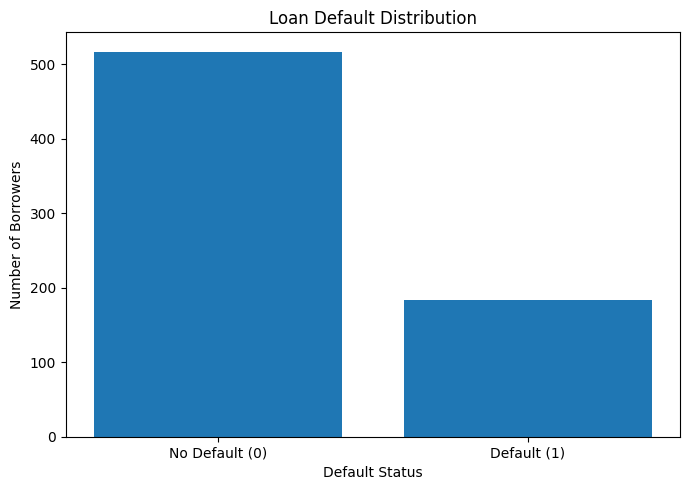

In [ ]:
# Visualize default distribution

default_counts = model_data["default"].value_counts().sort_index()

plt.figure(figsize=(7,5))
plt.bar(["No Default (0)", "Default (1)"], default_counts.values)
plt.title("Loan Default Distribution")
plt.xlabel("Default Status")
plt.ylabel("Number of Borrowers")
plt.tight_layout()
plt.show()


Visualize numerical feature distributions

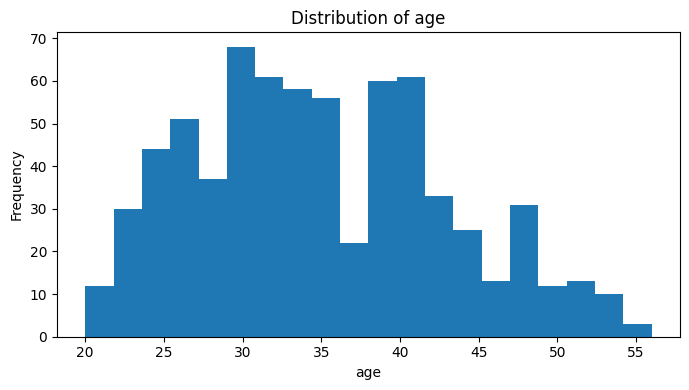

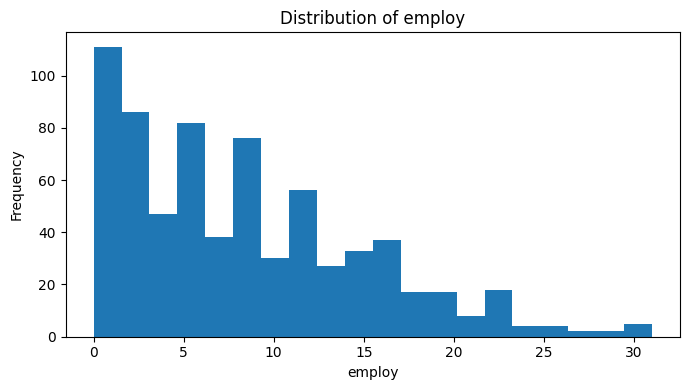

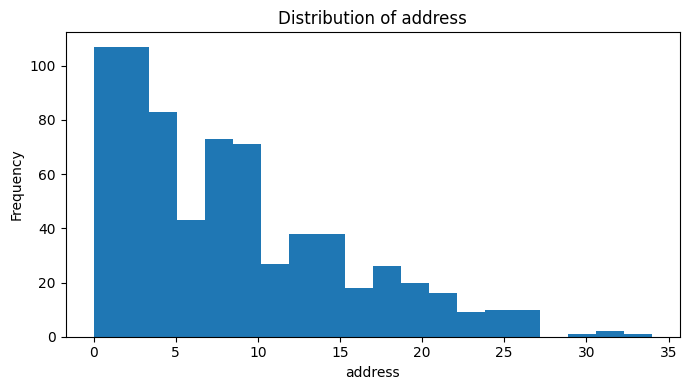

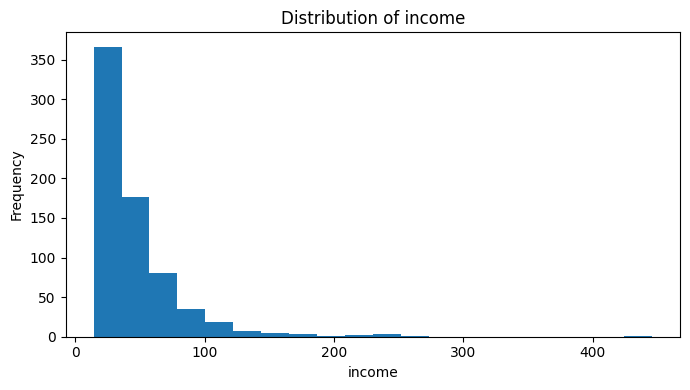

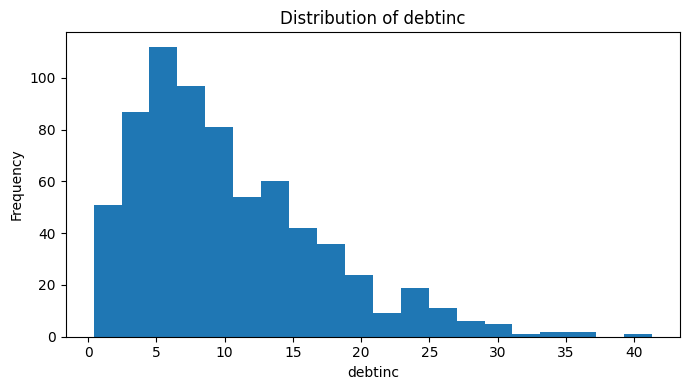

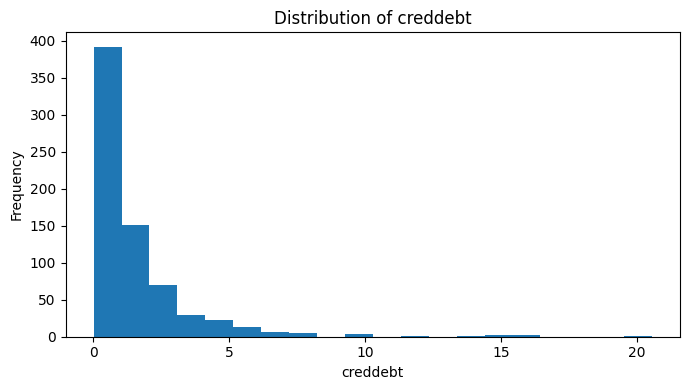

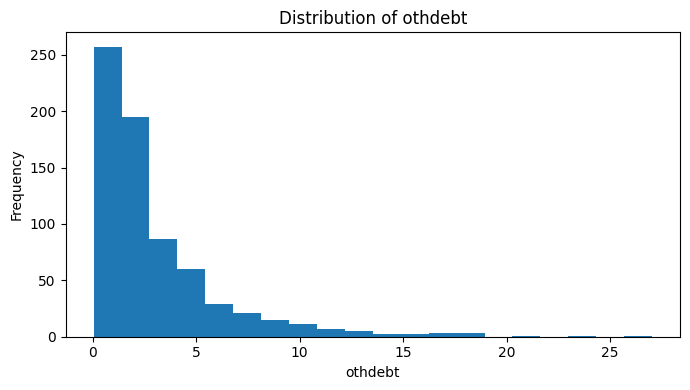

In [ ]:
numeric_features = ["age", "employ", "address", "income","debtinc", "creddebt", "othdebt"]

for feature in numeric_features:
    plt.figure(figsize=(7,4))
    plt.hist(model_data[feature], bins=20)
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()


 Explore relationships with loan default

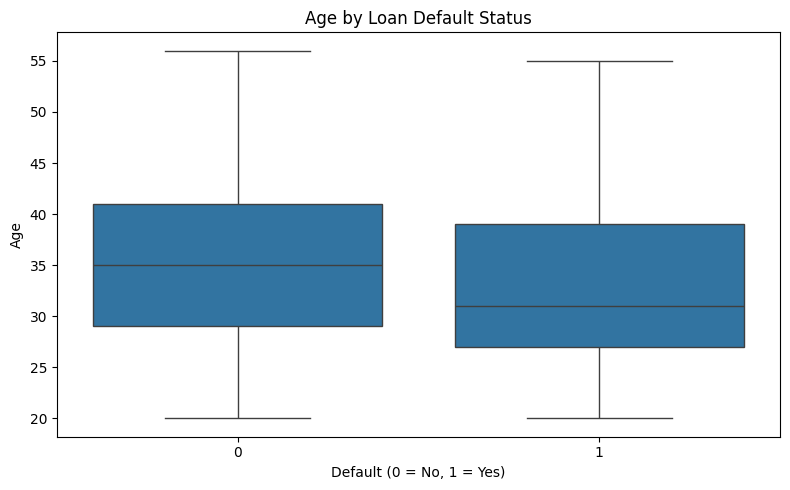

In [ ]:
# Age by default
plt.figure(figsize=(8,5))
sns.boxplot(data=model_data, x="default", y="age")
plt.title("Age by Loan Default Status")
plt.xlabel("Default (0 = No, 1 = Yes)")
plt.ylabel("Age")
plt.tight_layout()
plt.show()

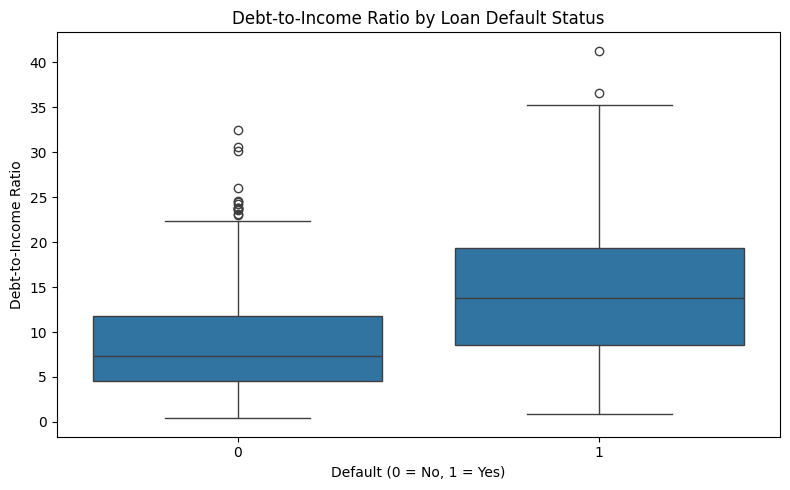

In [ ]:
# Debt-to-income ratio by default
plt.figure(figsize=(8,5))
sns.boxplot(data=model_data, x="default", y="debtinc")
plt.title("Debt-to-Income Ratio by Loan Default Status")
plt.xlabel("Default (0 = No, 1 = Yes)")
plt.ylabel("Debt-to-Income Ratio")
plt.tight_layout()
plt.show()

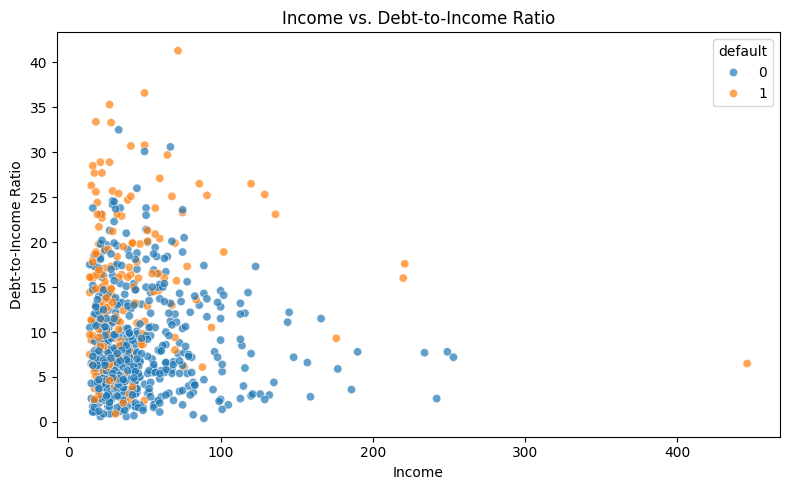

In [ ]:
# And Income versus debt-to-income ratio
plt.figure(figsize=(8,5))
sns.scatterplot(data=model_data,x="income",y="debtinc",hue="default",alpha=0.7)
plt.title("Income vs. Debt-to-Income Ratio")
plt.xlabel("Income")
plt.ylabel("Debt-to-Income Ratio")
plt.tight_layout()
plt.show()


Correlation analysis

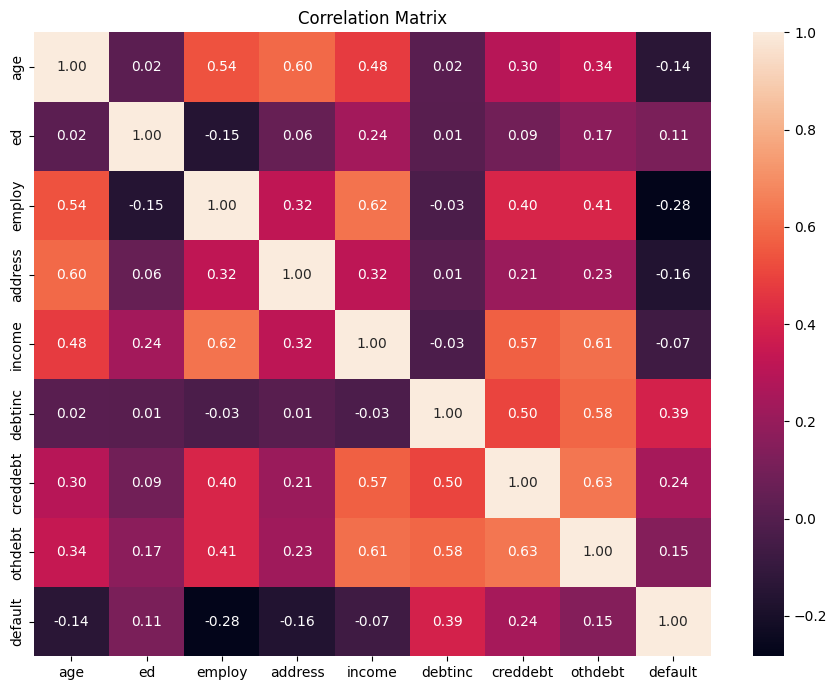

In [ ]:
correlation = model_data.corr(numeric_only=True)

plt.figure(figsize=(9,7))
sns.heatmap(correlation, annot=True, fmt=".2f")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


## Task 2: Feature Engineering

In [ ]:
# Selecting predictor variables and target

features = ["age", "ed", "employ", "address","income", "debtinc", "creddebt", "othdebt"]

X = model_data[features].copy()
y = model_data["default"].copy()

# Feature engineering
X["total_debt"] = X["creddebt"] + X["othdebt"]
X["debt_to_income_calc"] = (X["total_debt"] / X["income"].replace(0, np.nan))
X["employment_age_ratio"] = X["employ"] / X["age"]

# Handling any invalid values created during feature engineering
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

print("Features after feature engineering:")
print(X.columns.tolist())


Features after feature engineering:
['age', 'ed', 'employ', 'address', 'income', 'debtinc', 'creddebt', 'othdebt', 'total_debt', 'debt_to_income_calc', 'employment_age_ratio']


In [ ]:
#Spliting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))


Training observations: 560
Testing observations: 140


In [ ]:
# Scaling numerical features

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train),columns=X_train.columns,index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test),columns=X_test.columns,index=X_test.index)

print("Scaling Successfully Completed.")
display(X_train_scaled.head())


Scaling Successfully Completed.


,age,ed,employ,address,income,debtinc,creddebt,othdebt,total_debt,debt_to_income_calc,employment_age_ratio
213,0.021611,1.466908,-0.503414,-0.756841,-0.211106,-0.702432,-0.451109,-0.478207,-0.523145,-0.702432,-0.532366
425,0.145103,2.584552,-0.047738,-1.196347,-0.350681,-1.274069,-0.735950,-0.778613,-0.852413,-1.274069,-0.030327
72,1.503511,-0.768380,2.686320,1.880198,1.547532,0.410757,1.595515,1.720634,1.870363,0.410757,2.063283
608,0.145103,-0.768380,-0.199630,-0.903343,-0.043617,-0.582087,-0.216663,-0.410416,-0.375129,-0.582087,-0.206041
93,-0.348864,0.349264,-1.262874,-0.317334,-0.741489,-0.642259,-0.596855,-0.694527,-0.734532,-0.642259,-1.436037


## Task 3: Model Building and Evaluation



In [ ]:
# Training the Random Forest model

model = RandomForestClassifier(n_estimators=200,random_state=42,class_weight="balanced")
model.fit(X_train_scaled, y_train)

print("Random Forest model trained successfully.")


Random Forest model trained successfully.


In [ ]:
# Making predictions and calculate evaluation metrics

y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", round(accuracy, 4))


Accuracy: 0.8214


In [ ]:
print("\nConfusion_Matrix:")
print(cm)

print("\n_____________________Classification Report:_______________")
print(classification_report(y_test, y_pred, digits=4))


Confusion Matrix:
[[94  9]
 [16 21]]

_____________________Classification Report:_______________
              precision    recall  f1-score   support

           0     0.8545    0.9126    0.8826       103
           1     0.7000    0.5676    0.6269        37

    accuracy                         0.8214       140
   macro avg     0.7773    0.7401    0.7547       140
weighted avg     0.8137    0.8214    0.8150       140



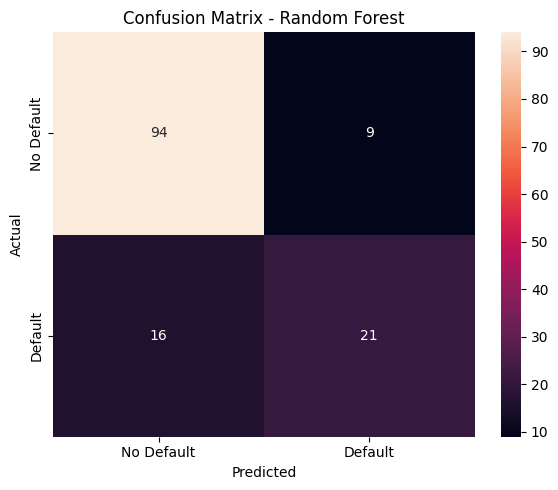

In [ ]:
# Visualizing the confusion matrix

plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt="d",
    xticklabels=["No Default", "Default"],
    yticklabels=["No Default", "Default"])
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


Feature Importance:


,Importance
employment_age_ratio,0.1499
creddebt,0.1148
debt_to_income_calc,0.1126
debtinc,0.1053
employ,0.0998
total_debt,0.0919
othdebt,0.0789
address,0.0773
income,0.0721
age,0.0721


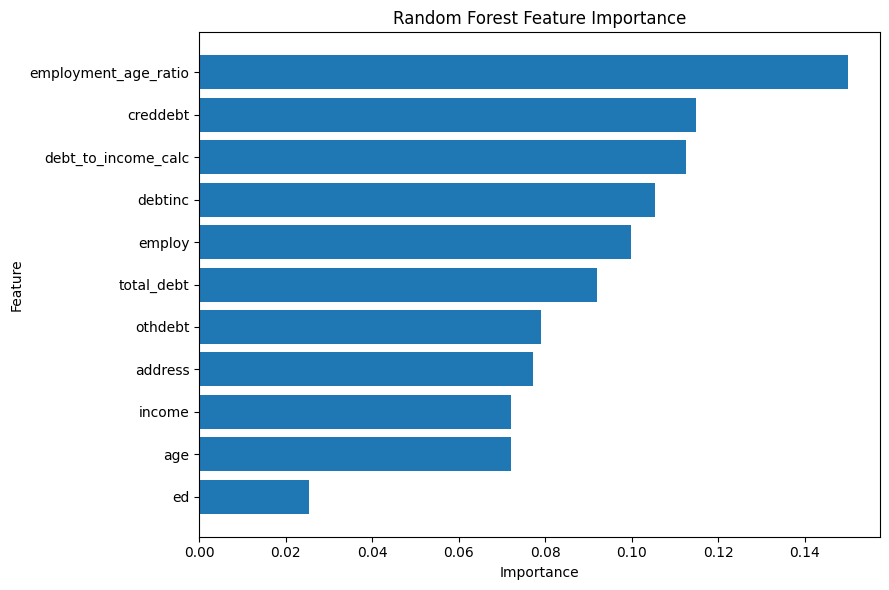

In [ ]:
# Feature importance

importance = pd.Series(model.feature_importances_,index=X.columns).sort_values(ascending=False)

print("Feature Importance:")
display(importance.round(4).to_frame("Importance"))

plt.figure(figsize=(9,6))
plt.barh(importance.index[::-1], importance.values[::-1])
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## Task 4: Explainability Using SHAP

SHAP is used to explain how individual features affect the Random Forest predictions. This provides more detailed information than feature importance alone.


In [ ]:
# Installing SHAP
!pip -q install shap


In [ ]:
# SHAP Analysis

# Explaining up to 100 test observations
explain_data = X_test_scaled.iloc[:100]

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(explain_data)

# Handling different SHAP output formats
if isinstance(shap_values, list):
    shap_default = shap_values[1]
elif np.asarray(shap_values).ndim == 3:
    shap_default = np.asarray(shap_values)[:, :, 1]
else:
    shap_default = np.asarray(shap_values)

print("The SHAP Analysis has been Successfully Completed!!.")


The SHAP Analysis has been Successfully Completed!!.


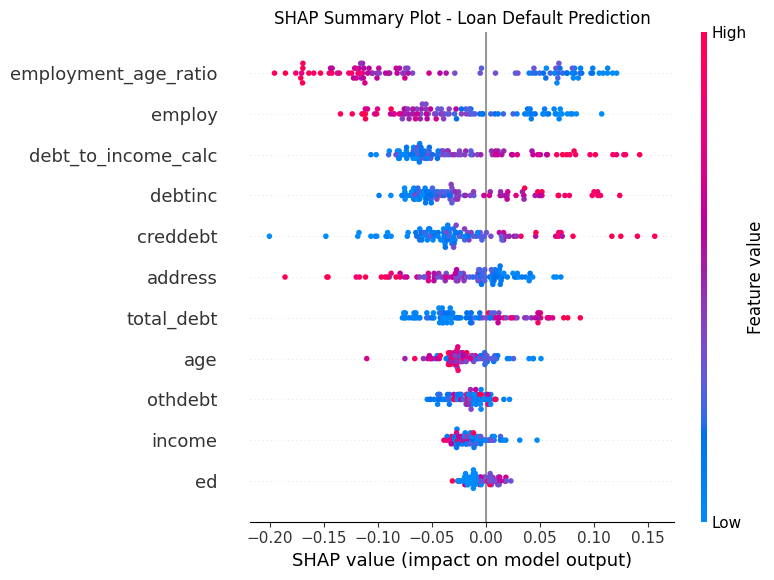

In [ ]:
#SHAP summary plot

shap.summary_plot(shap_default,explain_data,show=False)

plt.title("SHAP Summary Plot - Loan Default Prediction")
plt.tight_layout()
plt.show()


Mean Absolute SHAP Importance:


,Mean |SHAP|
employment_age_ratio,0.0957
employ,0.0564
debt_to_income_calc,0.0560
debtinc,0.0497
creddebt,0.0490
address,0.0380
total_debt,0.0372
age,0.0256
othdebt,0.0194
income,0.0178


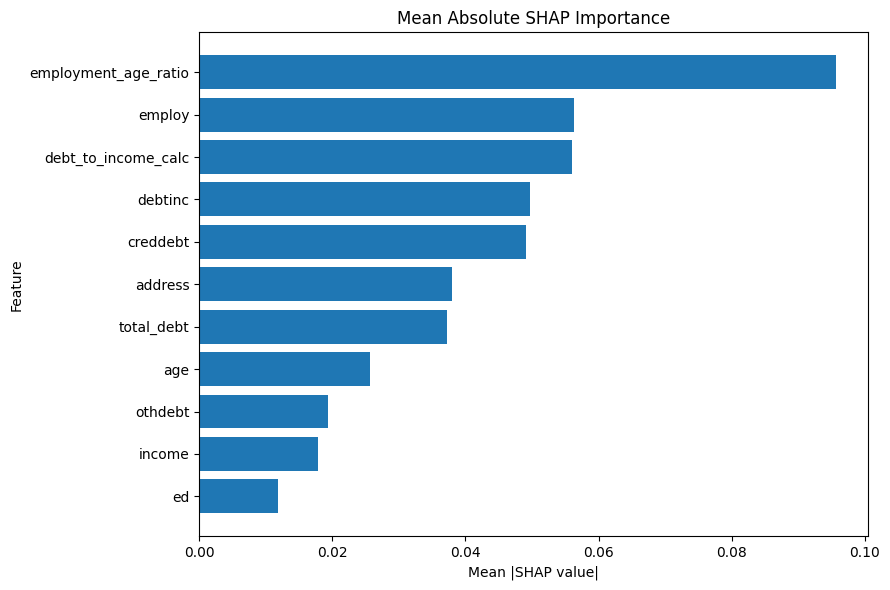

In [ ]:
# Mean absolute SHAP importance

mean_abs_shap = pd.Series(np.abs(shap_default).mean(axis=0),index=explain_data.columns).sort_values(ascending=False)

print("Mean Absolute SHAP Importance:")
display(mean_abs_shap.round(4).to_frame("Mean |SHAP|"))

plt.figure(figsize=(9,6))
plt.barh(mean_abs_shap.index[::-1], mean_abs_shap.values[::-1])
plt.title("Mean Absolute SHAP Importance")
plt.xlabel("Mean |SHAP value|")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()



Thee structure of the dataset cannot allow us to compare performance across demographic groups such as gender. The given dataset **bank-loan.csv** does not contain a gender variable. Instead, as an additional fairness analysis, model performance was compared across age groups:


In [ ]:
# Preparing test-set fairness data

fairness_data = model_data.loc[X_test.index, ["age"]].copy()
fairness_data["actual"] = y_test
fairness_data["predicted"] = y_pred

fairness_data["age_group"] = pd.cut(fairness_data["age"],
    bins=[19, 29, 39, 100],
    labels=["20-29", "30-39", "40+"])

display(fairness_data.head())


,age,actual,predicted,age_group
55,37,1,1,30-39
666,44,0,0,40+
249,35,0,0,30-39
421,43,0,0,40+
373,33,1,1,30-39


In [ ]:
# Calculating the fairness metrics by Age Group

fairness_results = []

for group, group_df in fairness_data.groupby("age_group", observed=True):
    group_cm = confusion_matrix(group_df["actual"],group_df["predicted"],labels=[0, 1])

    tn, fp, fn, tp = group_cm.ravel()

    group_accuracy = accuracy_score(group_df["actual"],group_df["predicted"])

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    false_positive_rate = fp / (fp + tn) if (fp + tn) > 0 else 0

    fairness_results.append({
        "Age Group": str(group),
        "Count": len(group_df),
        "Accuracy": group_accuracy,
        "Precision": precision,
        "Recall": recall,
        "False Positive Rate": false_positive_rate})

fairness_df = pd.DataFrame(fairness_results)

display(fairness_df.round(4))


,Age Group,Count,Accuracy,Precision,Recall,False Positive Rate
0,20-29,40,0.7500,0.7143,0.6250,0.1667
1,30-39,62,0.9032,0.8000,0.6667,0.0400
2,40+,38,0.7632,0.5000,0.3333,0.1034


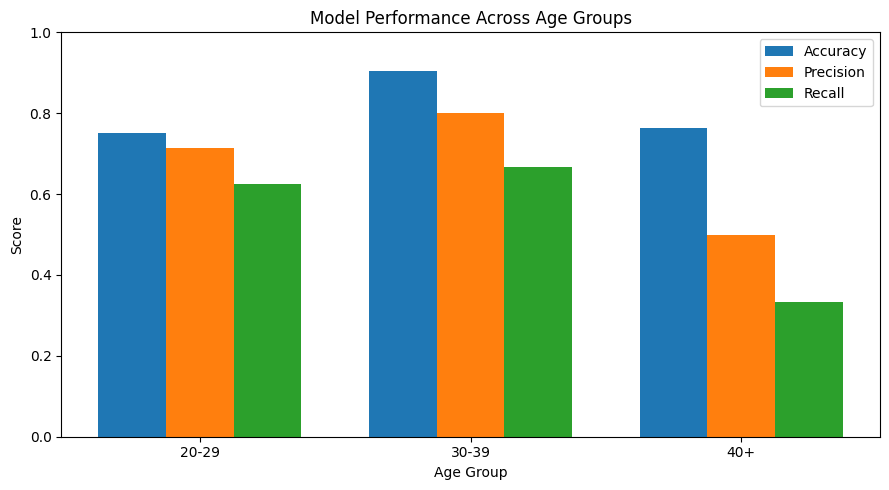

In [ ]:
# Visualizing fairness comparison

x = np.arange(len(fairness_df))
width = 0.25

plt.figure(figsize=(9,5))
plt.bar(x - width, fairness_df["Accuracy"], width, label="Accuracy")
plt.bar(x, fairness_df["Precision"], width, label="Precision")
plt.bar(x + width, fairness_df["Recall"], width, label="Recall")

plt.xticks(x, fairness_df["Age Group"])
plt.ylim(0, 1)
plt.xlabel("Age Group")
plt.ylabel("Score")
plt.title("Model Performance Across Age Groups")
plt.legend()
plt.tight_layout()
plt.show()


**Fairness Findings**

The model's performance above shows group 30-39 had the strongest overall performance, while the 40+ group had lower recall. The 20-29 group also had a higher false-positive rate than the 40+ group.



## Ethical Considerations

Fairness: ensuring the model analyse different groups fairly and does not discriminate. Privacy: borrowers' financial information was kept private, safe and secured. Transparency: using SHAP to understand why the model makes its predictions. Tell borrowers how their data is used.

Improvements: Use more and better data, check for model bias, regularly monitor the model, and do not rely on the model alone when making decisions

## Conclusion
This assignment project used machine learning to predict loan defaults from the provided dataset. The model achieved 82.14% accurate. The results showed that debt and employment were significant factors. In my opinion, the model can help with loan decisions  making, but it should be regularly checked, updated and peoples information must ve kept private and secured.

Colab Link

https://colab.research.google.com/drive/1v24vjvtxTU9JG4uAoLe9sUb9Yk5K3Sa3?usp=sharing